In [1]:
import matplotlib.pyplot as plt
import sys

from pathlib import Path
from typing import Tuple

module_path = str(Path("..").resolve())
if module_path not in sys.path:
    sys.path.append(module_path)

import utils.data_io as data_io

from config_handlers.rk_handler import RKHandler

In [2]:
# Importing RKHandler just to get the list of models and datasets
rk_hdl = RKHandler()
model_list = rk_hdl.get_model_list()
rk_hdl.set_curr_model(model_list[0])
ds_list = rk_hdl.get_ds_list()

all_ds = ds_list * 4
all_models = model_list * 4
all_models.sort()

In [3]:
def load_data(version: str = "det") -> Tuple[dict, dict]:
    samples = {m: {ds: {} for ds in ds_list} for m in model_list}
    summaries = {m: {ds: {} for ds in ds_list} for m in model_list}

    for model, ds in zip(all_models, all_ds):
        if version == "sam":
            base_fp = Path("0_stats", "similarity_nucleus")
        else:
            base_fp = Path("0_stats", "similarity")

        samples[model][ds] = data_io.load_json(
            base_fp.joinpath(model, ds, "samples.json")
        )
        summaries[model][ds] = data_io.load_json(
            base_fp.joinpath(model, ds, "summary.json")
        )

    return samples, summaries

In [4]:
samples_det, summaries_det = load_data("det")
samples_sam, summaries_sam = load_data("sam")

In [5]:
for model in model_list:
    print("=" * 10, f"{model.upper()}", "=" * 10)
    for ds in ds_list:
        print("-" * 50)
        print(f"{ds.upper()}")
        print("-" * 50)
        print("\t\t = Greedy = \t = Nucleus =")

        # Get GED
        avg_ged_det = summaries_det[model][ds]["ged"]
        avg_ged_sam = summaries_sam[model][ds]["ged"]
        print(f"Avg. GED: \t {avg_ged_det:.2f} \t\t {avg_ged_sam:.2f}")
        print("-" * 50)

        # Get IOU
        avg_iou_nodes_det = summaries_det[model][ds]["iou"]["iou_nodes"]
        avg_iou_edges_det = summaries_det[model][ds]["iou"]["iou_edges"]
        avg_iou_nodes_sam = summaries_sam[model][ds]["iou"]["iou_nodes"]
        avg_iou_edges_sam = summaries_sam[model][ds]["iou"]["iou_edges"]
        print(f"Avg. IOU (n): \t {avg_iou_nodes_det:.2f} \t\t {avg_iou_edges_det:.2f}")
        print(f"Avg. IOU (e): \t {avg_iou_edges_sam:.2f} \t\t {avg_iou_edges_sam:.2f}")
        print("-" * 50)

        # Get Cosine
        avg_cosine_det = summaries_det[model][ds]["cosine"]
        avg_cosine_sam = summaries_sam[model][ds]["cosine"]
        print(f"Avg. Cosine: \t {avg_cosine_det:.2f} \t\t {avg_cosine_sam:.2f}")
        print("-" * 50)

========== INTERNVL2 ==========
--------------------------------------------------
LLAVA-BENCH
--------------------------------------------------
		 = Greedy = 	 = Nucleus =
Avg. GED: 	 27.10 		 27.26
--------------------------------------------------
Avg. IOU (n): 	 0.05 		 0.02
Avg. IOU (e): 	 0.02 		 0.02
--------------------------------------------------
Avg. Cosine: 	 0.56 		 0.57
--------------------------------------------------
--------------------------------------------------
MMBENCH
--------------------------------------------------
		 = Greedy = 	 = Nucleus =
Avg. GED: 	 22.28 		 22.63
--------------------------------------------------
Avg. IOU (n): 	 0.09 		 0.02
Avg. IOU (e): 	 0.02 		 0.02
--------------------------------------------------
Avg. Cosine: 	 0.60 		 0.59
--------------------------------------------------
--------------------------------------------------
SEED
--------------------------------------------------
		 = Greedy = 	 = Nucleus =
Avg. GED: 	 22.37 		 

# Plot measures

In [6]:
DS_MAP = {
    "llava-bench": "LLaVa-Bench",
    "mmbench": "MMBench",
    "seed": "SEED-Bench 2",
    "vqav2": "VQA v2",
}

MODEL_MAP = {
    "internvl2": "InternVL2",
    "llava-1.6": "LLaVa-1.6",
    "minigpt4": "MiniGPT4",
    "sharegpt4v": "ShareGTP4V",
}

In [7]:
def plot_measure(data: dict, measure_key: str = "ged"):
    _, axes = plt.subplots(1, len(data.keys()), sharey=True, figsize=(15, 4))

    model_keys = list(data.keys())
    width = 0.8
    colours = ["#e6a6a3", "#f1c3c2", "#b0d3dc", "#8cbcc7"]
    hatches = ["..", "//", "xx", "++"]

    for idx, ax in enumerate(axes):
        ax.set_title(MODEL_MAP[model_keys[idx]])
        ax.tick_params(bottom=False)
        ax.yaxis.grid(True, linestyle="-", which="major", color="lightgrey", alpha=0.7)

        pos = 0
        curr_model_data = data[model_keys[idx]]
        for ds in curr_model_data:
            if measure_key in ["iou_nodes", "iou_edges"]:
                plot_dict = {
                    k: v["iou"][measure_key] for k, v in curr_model_data[ds].items()
                }
            else:
                # ged and cosine
                plot_dict = {k: v[measure_key] for k, v in curr_model_data[ds].items()}
            _ = ax.boxplot(
                plot_dict.values(),
                positions=[pos],
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor=colours[pos], hatch=hatches[pos]),
                notch=True,
                medianprops=dict(color="black"),
            )
            pos += 1

    ax.legend(DS_MAP.values(), loc="center left", ncol=1, bbox_to_anchor=(1, 0.5))

    axes[0].set_ylabel(measure_key.upper())
    plt.tight_layout()
    plt.show()


## SK vs. RK w/ greedy decoding

GED

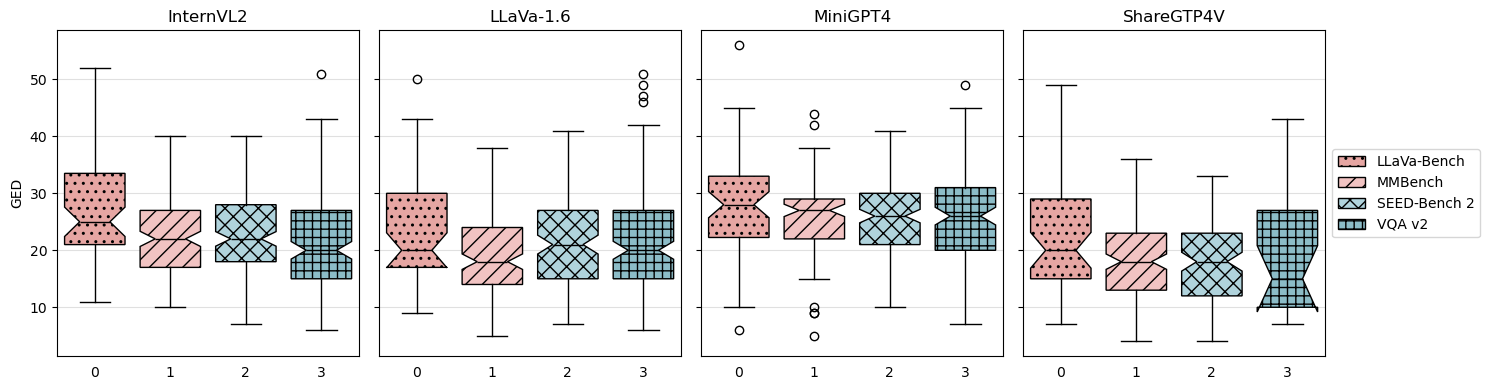

In [8]:
plot_measure(samples_det, measure_key="ged")

IOU

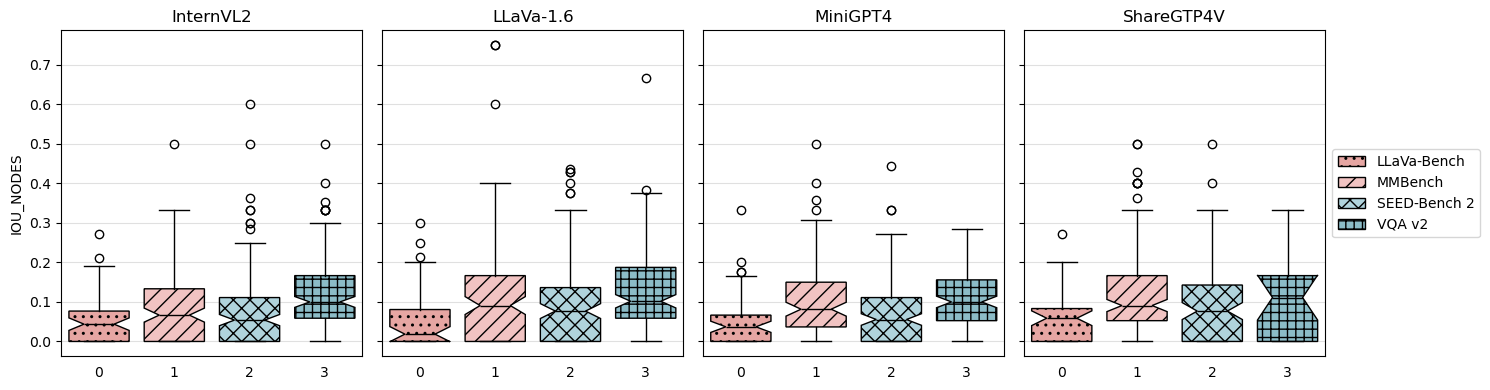

In [9]:
plot_measure(samples_det, measure_key="iou_nodes")

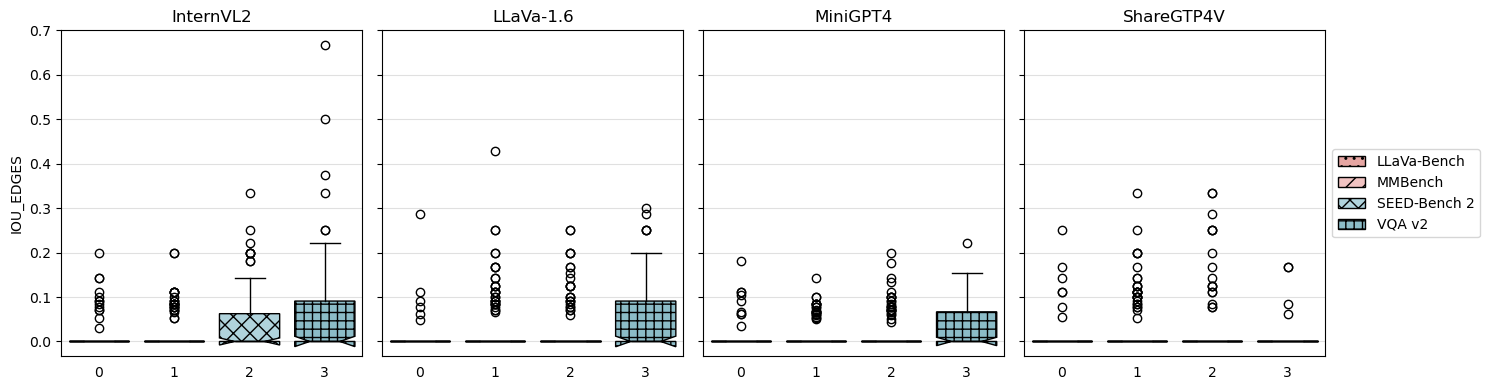

In [10]:
plot_measure(samples_det, measure_key="iou_edges")

Cosine

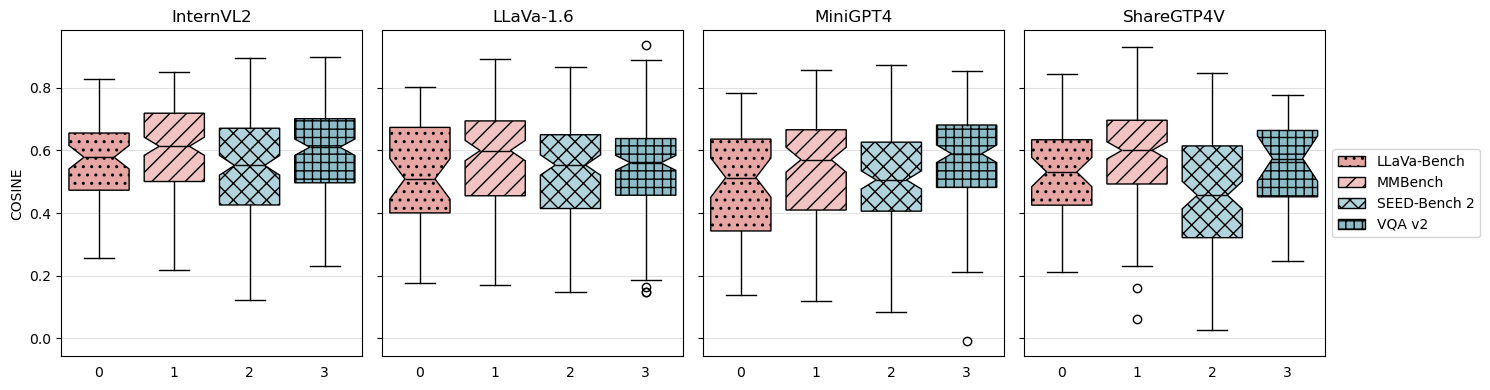

In [11]:
plot_measure(samples_det, measure_key="cosine")

## SK vs. RK w/ nucleus sampling

GED

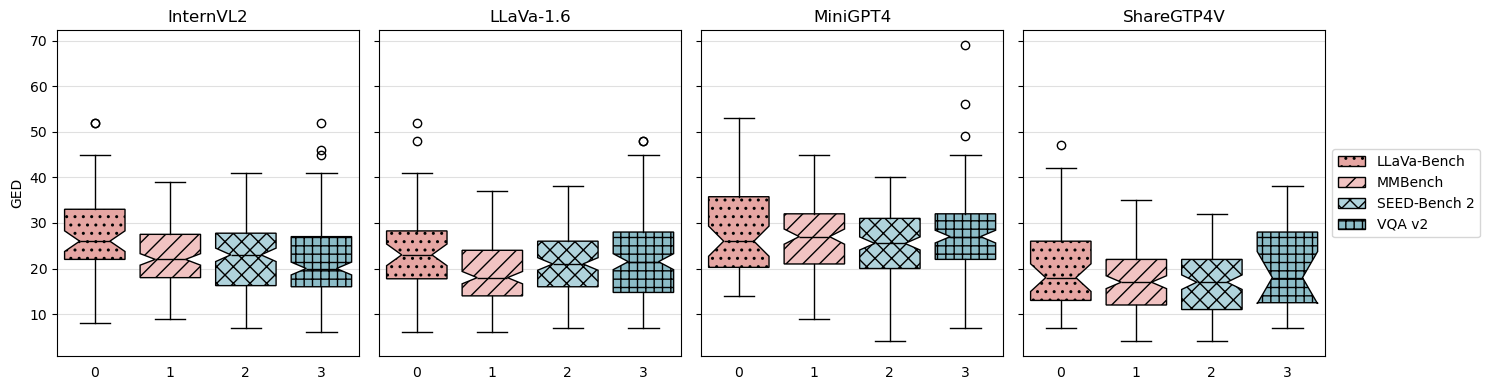

In [12]:
plot_measure(samples_sam, measure_key="ged")

IOU

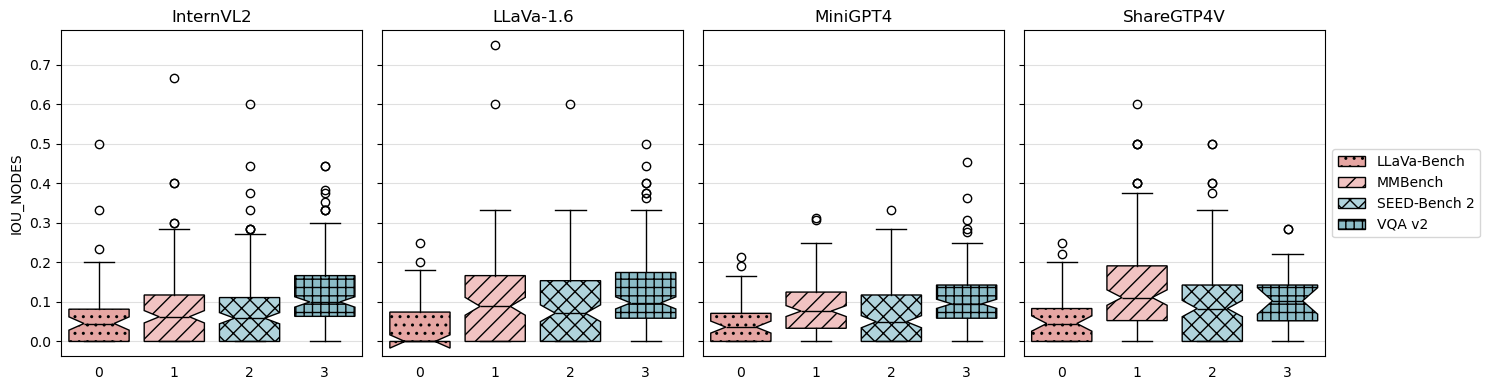

In [13]:
plot_measure(samples_sam, measure_key="iou_nodes")

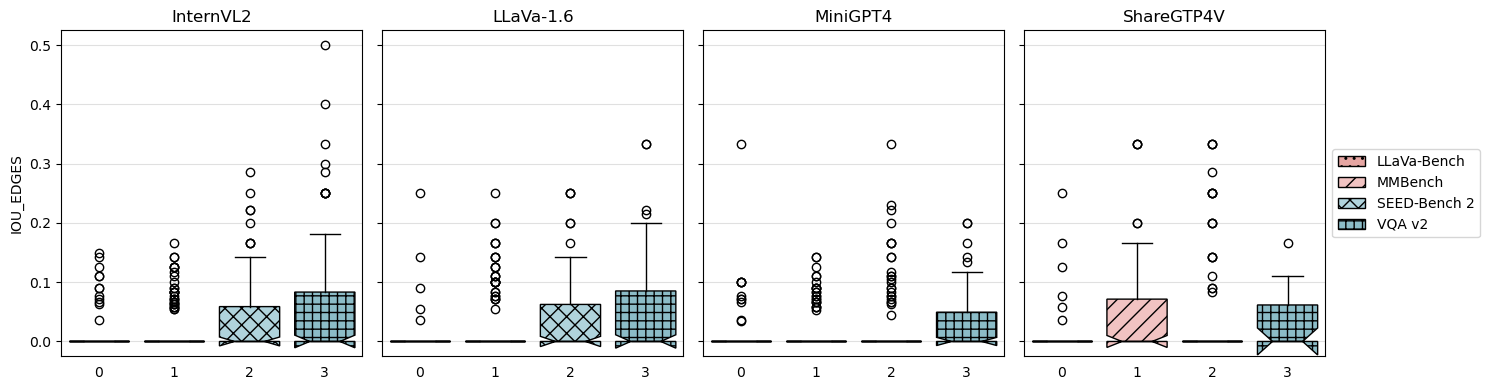

In [14]:
plot_measure(samples_sam, measure_key="iou_edges")

Cosine

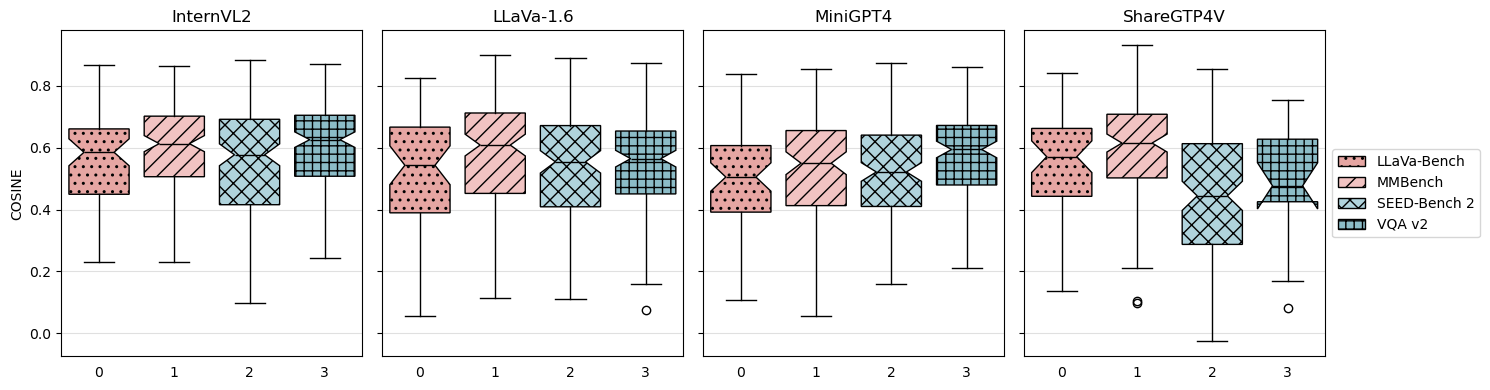

In [15]:
plot_measure(samples_sam, measure_key="cosine")